In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

In [2]:
# ============================================================
# 1) CHARGEMENT
# ============================================================
df_all = pd.read_csv("../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv", sep="\t")
target_sites = ["ds000030", "ds_cobre", "ds004302"]
target_diag = ["CONTROL", "SCHZ"]
mask = (df_all["site_id"].isin(target_sites) & df_all["diagnosis"].isin(target_diag))
df_viz = df_all.loc[mask].copy()
for col in ["age", "mean_fd"]:
    if col in df_viz.columns:
        df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')



/tmp/ipykernel_827715/1252178062.py:4: DtypeWarning: Columns (93968) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv("../datasets/schaefcomb_Wang2023Simple_dfschizo.tsv", sep="\t")


In [3]:
# ============================================================
# 2) TABLEAU 1
# ============================================================
def generate_table1(df):
    rows = []
    for site in target_sites:
        df_site = df[df["site_id"] == site]
        for diag in target_diag:
            sub_df = df_site[df_site["diagnosis"] == diag]
            if len(sub_df) == 0: continue
            age_str = f"{sub_df['age'].mean():.1f} ± {sub_df['age'].std():.1f}"
            fd_str = f"{sub_df['mean_fd'].mean():.2f} ± {sub_df['mean_fd'].std():.2f}"
            n_m, n_f = len(sub_df[sub_df['gender'] == 'M']), len(sub_df[sub_df['gender'] == 'F'])
            rows.append({"Site": site, "Groupe": diag, "N": len(sub_df), 
                         "Âge": age_str, "Sexe (M/F)": f"{n_m}/{n_f}", "Mouvement": fd_str})
    return pd.DataFrame(rows)

print(generate_table1(df_viz).to_markdown(index=False))



| Site     | Groupe   |   N | Âge         | Sexe (M/F)   | Mouvement   |
|:---------|:---------|----:|:------------|:-------------|:------------|
| ds000030 | CONTROL  | 122 | 31.6 ± 8.8  | 65/57        | 0.17 ± 0.13 |
| ds000030 | SCHZ     |  50 | 36.5 ± 8.9  | 38/12        | 0.27 ± 0.20 |
| ds_cobre | CONTROL  |  74 | 35.8 ± 11.6 | 51/23        | 0.28 ± 0.15 |
| ds_cobre | SCHZ     |  72 | 38.2 ± 13.9 | 58/14        | 0.43 ± 0.30 |
| ds004302 | CONTROL  |  25 | 39.8 ± 14.1 | 18/7         | 0.18 ± 0.08 |
| ds004302 | SCHZ     |  46 | 42.5 ± 10.7 | 36/10        | 0.19 ± 0.09 |


In [4]:
# ============================================================
# 3) FONCTIONS UTILITAIRES
# ============================================================
def get_star_from_p(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

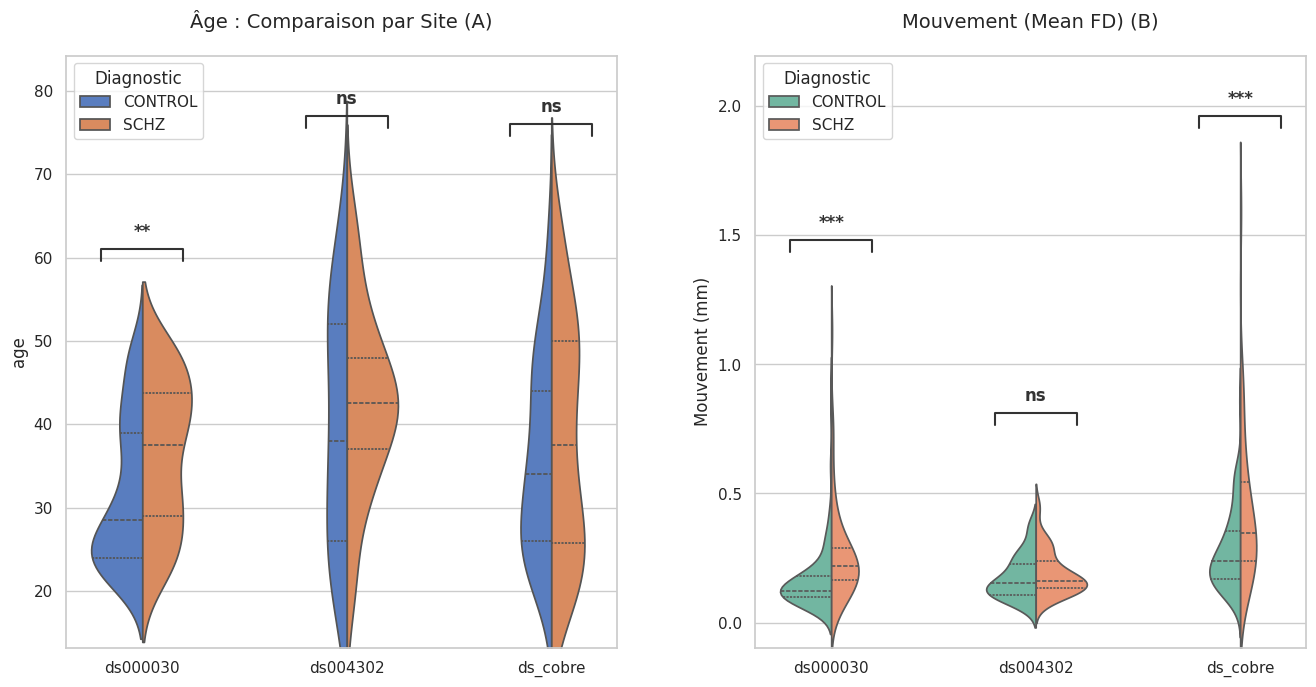

In [5]:
# ============================================================
# 4) FIGURE 1 : VARIABLES CONTINUES
# ============================================================
sns.set_theme(style="whitegrid")

fig1, axes = plt.subplots(1, 2, figsize=(16, 8))

def add_stat_annotation_dynamic(ax, df, x_col, y_col, hue_col):
    y_max_data = df[y_col].max()
    y_min_data = df[y_col].min()
    data_range = y_max_data - y_min_data
    
    sites_order = [t.get_text() for t in ax.get_xticklabels()]
    highest_y_reached = y_max_data 

    for site in sites_order:
        site_data = df[df[x_col] == site]
        g1 = site_data[site_data[hue_col] == target_diag[0]][y_col].dropna()
        g2 = site_data[site_data[hue_col] == target_diag[1]][y_col].dropna()
        
        if len(g1) < 2 or len(g2) < 2: continue

        _, p_val = ttest_ind(g1, g2)
        star = get_star_from_p(p_val)
        
        local_max = max(g1.max(), g2.max())
        
        violin_clearance = data_range * 0.20 
        h = data_range * 0.03
        
        y_line = local_max + violin_clearance
        y_text = y_line + h
        
        if y_text > highest_y_reached:
            highest_y_reached = y_text
        
        x_idx = sites_order.index(site)
        col = '#333333'
        
        ax.plot([x_idx-0.2, x_idx-0.2, x_idx+0.2, x_idx+0.2], 
                [y_line, y_line+h, y_line+h, y_line], 
                lw=1.5, c=col)
        
        ax.text(x_idx, y_text + (data_range * 0.02), star, ha='center', va='bottom', 
                color=col, fontsize=12, fontweight='bold')

    return highest_y_reached

# --- PLOT AGE ---
sns.violinplot(data=df_viz, x="site_id", y="age", hue="diagnosis", 
               split=True, inner="quart", palette="muted", ax=axes[0], 
               cut=2, width=0.5) 

axes[0].set_title("Âge : Comparaison par Site (A)", pad=20, fontsize=14)
axes[0].set_xlabel("")
axes[0].legend(loc='upper left', title="Diagnostic")

max_h_age = add_stat_annotation_dynamic(axes[0], df_viz, "site_id", "age", "diagnosis")
data_range_age = df_viz["age"].max() - df_viz["age"].min()
axes[0].set_ylim(bottom=df_viz["age"].min() - (data_range_age * 0.1), 
                 top=max_h_age + (data_range_age * 0.15))

# --- PLOT MOUVEMENT ---
sns.violinplot(data=df_viz, x="site_id", y="mean_fd", hue="diagnosis", 
               split=True, inner="quart", palette="Set2", ax=axes[1], 
               cut=2, width=0.5)

axes[1].set_title("Mouvement (Mean FD) (B)", pad=20, fontsize=14)
axes[1].set_xlabel("")
axes[1].set_ylabel("Mouvement (mm)")
axes[1].legend(loc='upper left', title="Diagnostic")

max_h_fd = add_stat_annotation_dynamic(axes[1], df_viz, "site_id", "mean_fd", "diagnosis")
data_range_fd = df_viz["mean_fd"].max() - df_viz["mean_fd"].min()
axes[1].set_ylim(bottom=df_viz["mean_fd"].min() - (data_range_fd * 0.1), 
                 top=max_h_fd + (data_range_fd * 0.15))

plt.subplots_adjust(top=0.85, wspace=0.25)
plt.show()



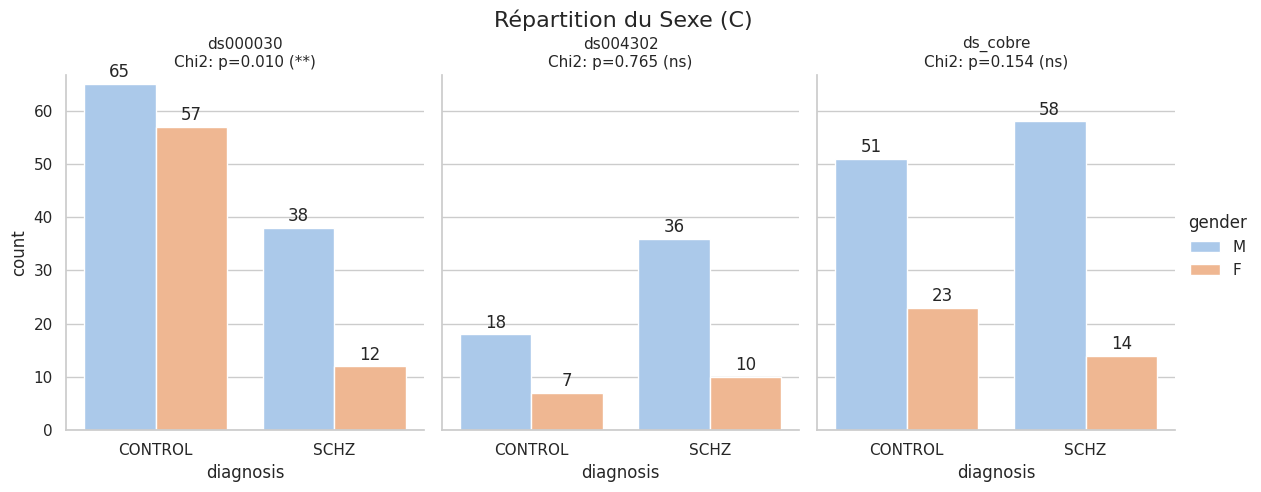

In [6]:
# ============================================================
# 5) FIGURE 2 : SEXE 
# ============================================================
g = sns.catplot(
    data=df_viz, x="diagnosis", hue="gender", col="site_id", 
    kind="count", height=5, aspect=0.8, palette="pastel"
)

for ax in g.axes.flat:
    site = ax.get_title().split(" = ")[-1]
    
    df_s = df_viz[df_viz["site_id"] == site]
    cont = pd.crosstab(df_s['diagnosis'], df_s['gender'])
    p_str = "N/A"
    if cont.shape == (2, 2):
        _, p, _, _ = chi2_contingency(cont)
        star = get_star_from_p(p)
        p_str = f"p={p:.3f} ({star})"
    
    ax.set_title(f"{site}\nChi2: {p_str}", fontsize=11)
    
    for c in ax.containers:
        ax.bar_label(c, padding=2)
    
    y_max = max([bar.get_height() for bar in ax.patches])
    ax.set_ylim(top=y_max * 1.15)

g.fig.subplots_adjust(top=0.85) 
g.fig.suptitle("Répartition du Sexe (C)", fontsize=16)

plt.show()

In [7]:
# ============================================================
# 6) ANALYSE DES VALEURS MANQUANTES (NAN) DANS LES COLONNES 'CORR'
# ============================================================
# 1. Identifier les colonnes
corr_cols = [col for col in df_viz.columns if col.startswith("corr")]

print(f"\n[INFO] Nombre de colonnes 'corr' trouvées : {len(corr_cols)}")

if len(corr_cols) > 0:
    # 2. Calculer la proportion de NaN (isna().mean() donne directement le %)
    nan_stats = df_viz[corr_cols].isna().mean()
    
    # 3. Calcul global pour avoir une idée d'ensemble
    global_nan_rate = df_viz[corr_cols].isna().sum().sum() / df_viz[corr_cols].size
    print(f"[INFO] Proportion globale de NaN (toutes cellules 'corr' confondues) : {global_nan_rate:.2%}")

    # 4. Filtrer et afficher celles qui posent problème
    # On ne garde que celles qui ont > 0% de NaN et on trie par ordre décroissant
    problematic_cols = nan_stats[nan_stats > 0].sort_values(ascending=False)

    if not problematic_cols.empty:
        print(f"\n[DÉTAIL] Il y a {len(problematic_cols)} colonnes contenant des NaN.")
        print("Voici les 10 colonnes avec le plus de valeurs manquantes :")
        print(problematic_cols.head(10))
        
        # Optionnel : Visualisation rapide de la distribution des manquants
        # plt.figure(figsize=(10, 4))
        # sns.histplot(problematic_cols, bins=20)
        # plt.title("Distribution du % de NaN par colonne")
        # plt.xlabel("Proportion de NaN")
        # plt.show()
    else:
        print("[OK] Aucune valeur manquante (NaN) détectée dans les colonnes 'corr'.")

else:
    print("[WARNING] Aucune colonne commençant par 'corr' n'est présente dans df_viz.")


[INFO] Nombre de colonnes 'corr' trouvées : 93961
[INFO] Proportion globale de NaN (toutes cellules 'corr' confondues) : 10.53%

[DÉTAIL] Il y a 78208 colonnes contenant des NaN.
Voici les 10 colonnes avec le plus de valeurs manquantes :
corr_423_431    1.0
corr_417_431    1.0
corr_413_418    1.0
corr_415_418    1.0
corr_414_418    1.0
corr_170_418    1.0
corr_170_431    1.0
corr_412_431    1.0
corr_412_418    1.0
corr_411_418    1.0
dtype: float64
